# Visualização do pré-processamento e localização da aorta

## Objetivo

Visualiza fatias completas, pré-processamento, Hough e mapas de vesselness em exames de referência do ImageCAS.

In [1]:
# ruff: noqa: E402
import sys
from pathlib import Path

NOTEBOOK_CWD = Path.cwd().resolve()
for candidate in (
    NOTEBOOK_CWD,
    NOTEBOOK_CWD.parent,
    NOTEBOOK_CWD.parent.parent,
):
    src_dir = candidate / "src"
    if src_dir.exists():
        if str(src_dir) not in sys.path:
            sys.path.insert(0, str(src_dir))
        break

from utils.project.notebook_env import configure_notebook_environment  # noqa: E402

REPO_ROOT = configure_notebook_environment()


In [2]:
from IPython.display import Image, display
from utils.project.notebook_env import resolve_imagecas_base_path
import numpy as np
import matplotlib.pyplot as plt

from utils import (
    load_config_json,
    scale_config_to_resolution,
    run_core_preprocessing_pipeline,
    plot_mip_projection,
    save_volume_slice_figure,
    plot_preprocessing_grid,
    plot_stage,
    compute_vesselness_maps,
    plot_vesselness_mip,
    load_raw_img_and_label,
    get_or_detect_aorta_circles,
    get_initial_circle_diagnostics,
    plot_hough_initial_circle,
    plot_hough_refinement_candidates,
    plot_hough_refined_circle,
    visualize_circles_on_slices,

)

# ==================== Configuracao global dos plots ====================
PLOT_PRESETS = {
    "draft": {
        "dpi": 180,
        "show_titles": True,
        "show_subtitles": True,
        "show_colorbar": True,
        "vesselness_cmap": "gray",
        "invert_label_cmap": False,
    },
    "publication": {
        "dpi": 600,
        "show_titles": False,
        "show_subtitles": False,
        "show_colorbar": False,
        "vesselness_cmap": "gray",
        "invert_label_cmap": True,
    },
}

PLOT_PRESET = "publication"  # "draft" ou "publication"

if PLOT_PRESET not in PLOT_PRESETS:
    raise ValueError(
        f"Preset invalido: {PLOT_PRESET}. Opcoes: {list(PLOT_PRESETS.keys())}"
    )

_plot_cfg = PLOT_PRESETS[PLOT_PRESET]

PLOT_EXPORT_DPI = _plot_cfg["dpi"]
PLOT_DPI = 100  # pré-visualização compacta; não altera os volumes
PLOT_SHOW_TITLES = _plot_cfg["show_titles"]
PLOT_SHOW_SUBTITLES = _plot_cfg["show_subtitles"]
PLOT_SHOW_COLORBAR = _plot_cfg["show_colorbar"]
PLOT_VESSELNESS_CMAP = _plot_cfg["vesselness_cmap"]
PLOT_INVERT_LABEL_CMAP = _plot_cfg["invert_label_cmap"]

RUN_VESSELNESS = False


## Configuração

Ajuste nesta seção apenas os parâmetros da análise; o pipeline base não é alterado.

## Carregamento

In [3]:
BASE_PATH = resolve_imagecas_base_path()

CONFIG_FILE = REPO_ROOT / "config/pipeline_config.json"
RESOLUTION = 'mid'  # 'high' ou 'mid'

if not CONFIG_FILE.exists():
    raise FileNotFoundError(f"Arquivo de configuracao nao encontrado: {CONFIG_FILE}")

CONFIG = load_config_json(str(CONFIG_FILE), {})
if RESOLUTION == 'high':
    CONFIG['DOWNSCALE_FACTORS'] = [1, 1, 1]
CONFIG = scale_config_to_resolution(CONFIG)

print(f"Configuracao carregada de: {CONFIG_FILE}")

ids = np.array([90, 774])
data = {}

for id in ids:
    img_path = f"{BASE_PATH}/{id}.img.nii.gz"
    label_path = f"{BASE_PATH}/{id}.label.nii.gz"
    nii_img, nii_label = load_raw_img_and_label(img_path, label_path)
    img = np.asarray(nii_img.get_fdata(), dtype=np.float32)
    label = np.asarray(nii_label.get_fdata(), dtype=np.uint8)
    spacing = nii_img.header.get_zooms()

    data[id] = {
        "img": img,
        "label": label,
        "spacing": spacing,
    }

print(f"IDs selecionados: {ids.tolist()}")


Configuracao carregada de: /home/matheus/workspace/coronary-centerline-detection/config/pipeline_config.json
IDs selecionados: [90, 774]


## Fatias axiais da imagem original

Cada célula abaixo mostra uma única fatia completa e salva a figura em `output/segmentation/analysis/image_slices/` com 300 dpi.

In [4]:
SLICE_IMAGE_ID = int(ids[0])
SLICE_FRACTIONS = (0.25, 0.50, 0.75, 1.00)
SLICE_WINDOW_CENTER_HU = 300
SLICE_WINDOW_WIDTH_HU = 800
SLICE_DPI = 300
SLICE_OUTPUT_SIZE_PX = (256, 256)
SLICE_ORIGIN = "upper"  # mesma convenção usada pelo Hough
SLICE_PADDING_FRACTION = 0.03

slice_volume = data[SLICE_IMAGE_ID]["img"]
slice_indices = [
    round(fraction * (slice_volume.shape[2] - 1))
    for fraction in SLICE_FRACTIONS
]
slice_vmin = SLICE_WINDOW_CENTER_HU - SLICE_WINDOW_WIDTH_HU / 2
slice_vmax = SLICE_WINDOW_CENTER_HU + SLICE_WINDOW_WIDTH_HU / 2
slice_output_dir = REPO_ROOT / "output/segmentation/analysis/image_slices"

print(f"Imagem: {SLICE_IMAGE_ID} | shape: {slice_volume.shape}")
print(f"Fatias selecionadas: {slice_indices}")

Imagem: 90 | shape: (512, 512, 275)
Fatias selecionadas: [68, 137, 206, 274]


### Fatia em 25% do volume

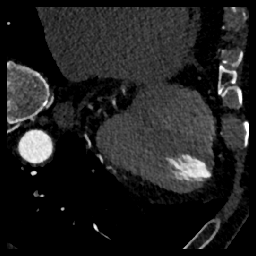

Fatia 68/274 | /home/matheus/workspace/coronary-centerline-detection/output/segmentation/analysis/image_slices/image_90_axial_slice_0068.png


In [5]:
slice_index = slice_indices[0]
slice_path = slice_output_dir / (
    f"image_{SLICE_IMAGE_ID}_axial_slice_{slice_index:04d}.png"
)
save_volume_slice_figure(
    slice_volume,
    slice_index,
    slice_path,
    vmin=slice_vmin,
    vmax=slice_vmax,
    origin=SLICE_ORIGIN,
    dpi=SLICE_DPI,
    padding_fraction=SLICE_PADDING_FRACTION,
    output_size_px=SLICE_OUTPUT_SIZE_PX,
)
display(Image(filename=str(slice_path)))
print(f"Fatia {slice_index}/{slice_volume.shape[2] - 1} | {slice_path}")

### Fatia em 50% do volume

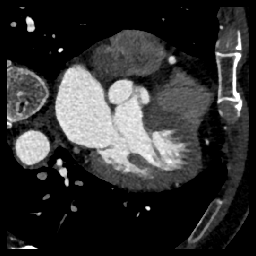

Fatia 137/274 | /home/matheus/workspace/coronary-centerline-detection/output/segmentation/analysis/image_slices/image_90_axial_slice_0137.png


In [6]:
slice_index = slice_indices[1]
slice_path = slice_output_dir / (
    f"image_{SLICE_IMAGE_ID}_axial_slice_{slice_index:04d}.png"
)
save_volume_slice_figure(
    slice_volume,
    slice_index,
    slice_path,
    vmin=slice_vmin,
    vmax=slice_vmax,
    origin=SLICE_ORIGIN,
    dpi=SLICE_DPI,
    padding_fraction=SLICE_PADDING_FRACTION,
    output_size_px=SLICE_OUTPUT_SIZE_PX,
)
display(Image(filename=str(slice_path)))
print(f"Fatia {slice_index}/{slice_volume.shape[2] - 1} | {slice_path}")

### Fatia em 75% do volume

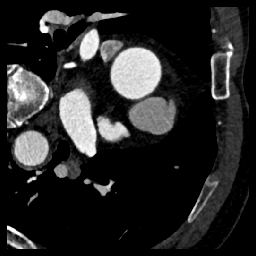

Fatia 206/274 | /home/matheus/workspace/coronary-centerline-detection/output/segmentation/analysis/image_slices/image_90_axial_slice_0206.png


In [7]:
slice_index = slice_indices[2]
slice_path = slice_output_dir / (
    f"image_{SLICE_IMAGE_ID}_axial_slice_{slice_index:04d}.png"
)
save_volume_slice_figure(
    slice_volume,
    slice_index,
    slice_path,
    vmin=slice_vmin,
    vmax=slice_vmax,
    origin=SLICE_ORIGIN,
    dpi=SLICE_DPI,
    padding_fraction=SLICE_PADDING_FRACTION,
    output_size_px=SLICE_OUTPUT_SIZE_PX,
)
display(Image(filename=str(slice_path)))
print(f"Fatia {slice_index}/{slice_volume.shape[2] - 1} | {slice_path}")

### Fatia em 100% do volume

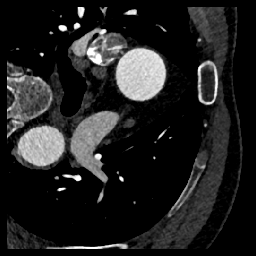

Fatia 274/274 | /home/matheus/workspace/coronary-centerline-detection/output/segmentation/analysis/image_slices/image_90_axial_slice_0274.png


In [8]:
slice_index = slice_indices[3]
slice_path = slice_output_dir / (
    f"image_{SLICE_IMAGE_ID}_axial_slice_{slice_index:04d}.png"
)
save_volume_slice_figure(
    slice_volume,
    slice_index,
    slice_path,
    vmin=slice_vmin,
    vmax=slice_vmax,
    origin=SLICE_ORIGIN,
    dpi=SLICE_DPI,
    padding_fraction=SLICE_PADDING_FRACTION,
    output_size_px=SLICE_OUTPUT_SIZE_PX,
)
display(Image(filename=str(slice_path)))
print(f"Fatia {slice_index}/{slice_volume.shape[2] - 1} | {slice_path}")

## Análise

As subseções abaixo apresentam as métricas, tabelas ou visualizações do objetivo definido.

## MIP das Imagens

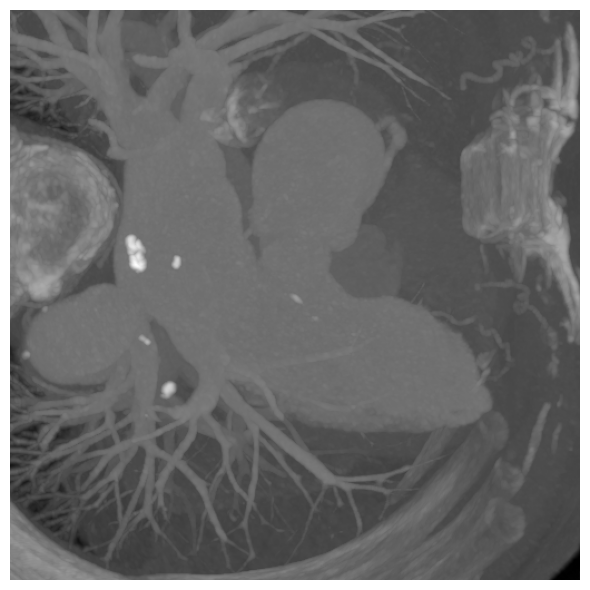

In [9]:
plot_mip_projection(
    data[ids[0]]["img"],
    title="MIP axial - Imagem",
    show_title=PLOT_SHOW_TITLES,
    views=["axial"],
    show_labels=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)

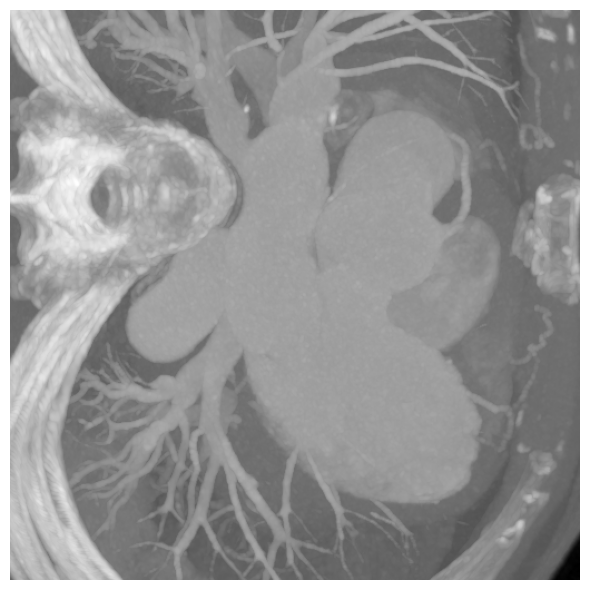

In [10]:
plot_mip_projection(
    data[ids[1]]["img"],
    title="MIP axial - Imagem",
    show_title=PLOT_SHOW_TITLES,
    views=["axial"],
    show_labels=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)

## MIP dos rótulos

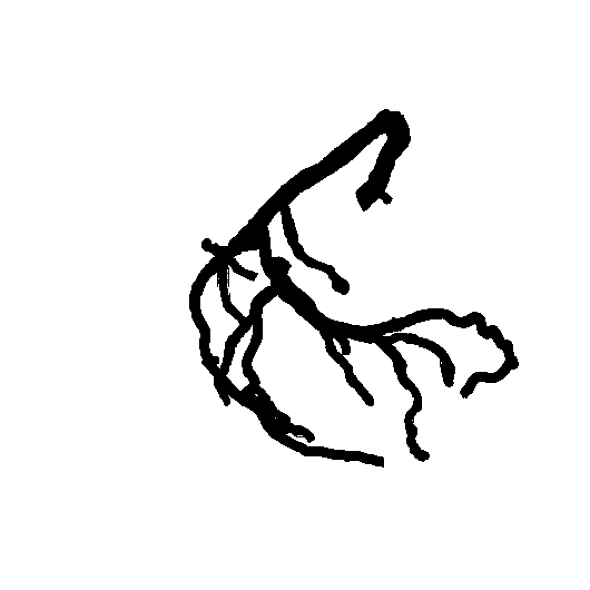

In [11]:
plot_mip_projection(
    data[ids[0]]["label"],
    title="MIP axial - Rotulo",
    show_title=PLOT_SHOW_TITLES,
    invert_cmap=PLOT_INVERT_LABEL_CMAP,
    views=["axial"],
    show_labels=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)

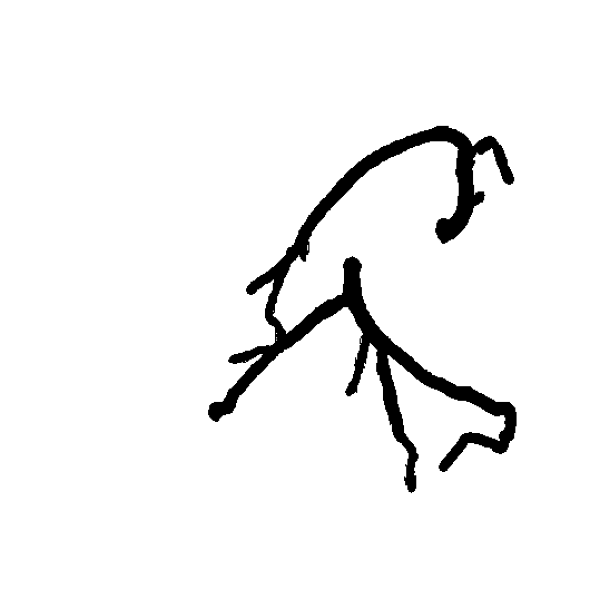

In [12]:
plot_mip_projection(
    data[ids[1]]["label"],
    title="MIP axial - Rotulo",
    show_title=PLOT_SHOW_TITLES,
    invert_cmap=PLOT_INVERT_LABEL_CMAP,
    views=["axial"],
    show_labels=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)

## Imagem reduzida, limiarizada e LCC (IDs 90 e 774)


In [13]:
preprocessed = {}

for img_id in ids:
    down_image, thresh_image, lcc_image, thresh_vals = run_core_preprocessing_pipeline(
        data[img_id]["img"],
        downscale_factors=CONFIG["DOWNSCALE_FACTORS"],
        max_threshold_percentile=CONFIG["MAX_THRESHOLD_PERCENTILE"],
        lcc_per_slice=True,
        use_opencv=False
    )

    center_slice = down_image.shape[2] // 2
    preprocessed[img_id] = {
        "down_image": down_image,
        "thresh_image": thresh_image,
        "lcc_image": lcc_image,
        "thresh_vals": thresh_vals,
        "center_slice": center_slice,
    }

    print(
        f"ID {img_id}: shape={down_image.shape} | fatia central={center_slice}"
    )


ID 90: shape=(256, 256, 275) | fatia central=137
ID 774: shape=(256, 256, 235) | fatia central=117


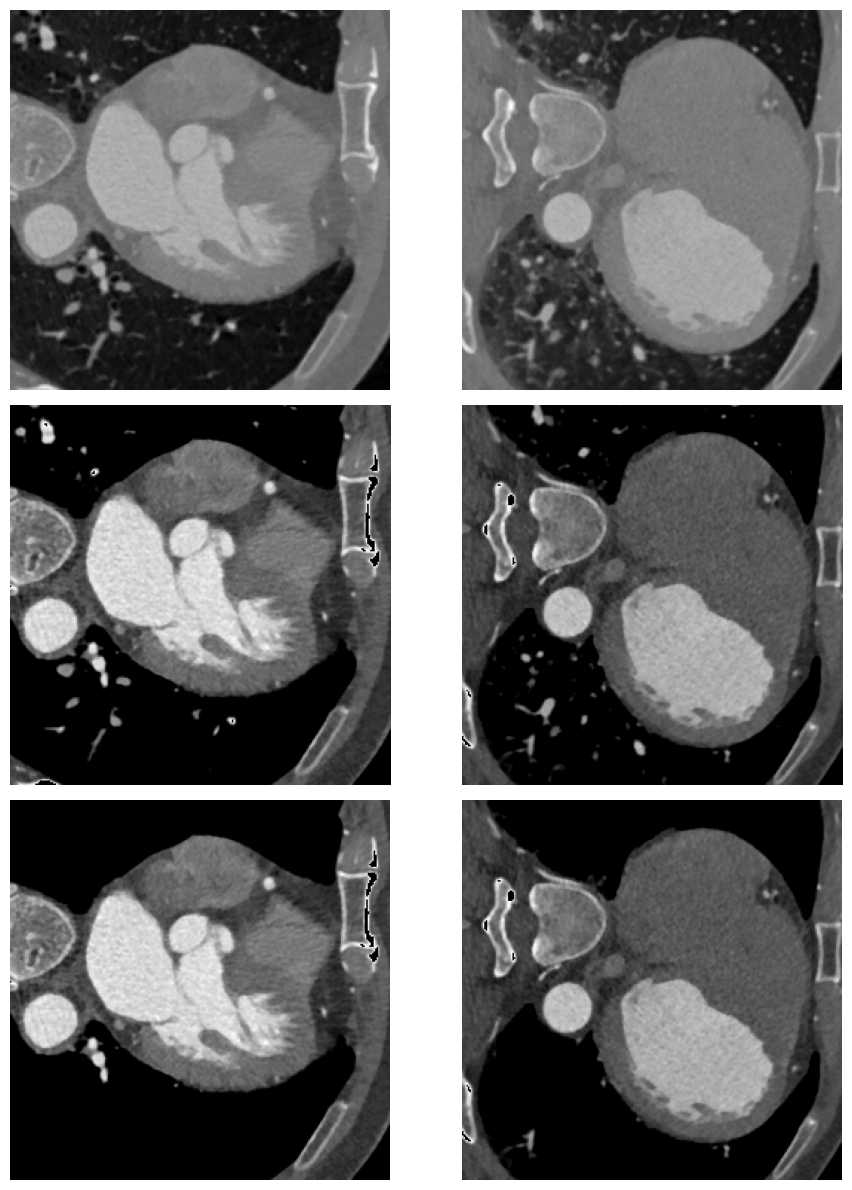

In [14]:
plot_preprocessing_grid(
    preprocessed,
    ids_to_plot=ids,
    mode="slice",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)


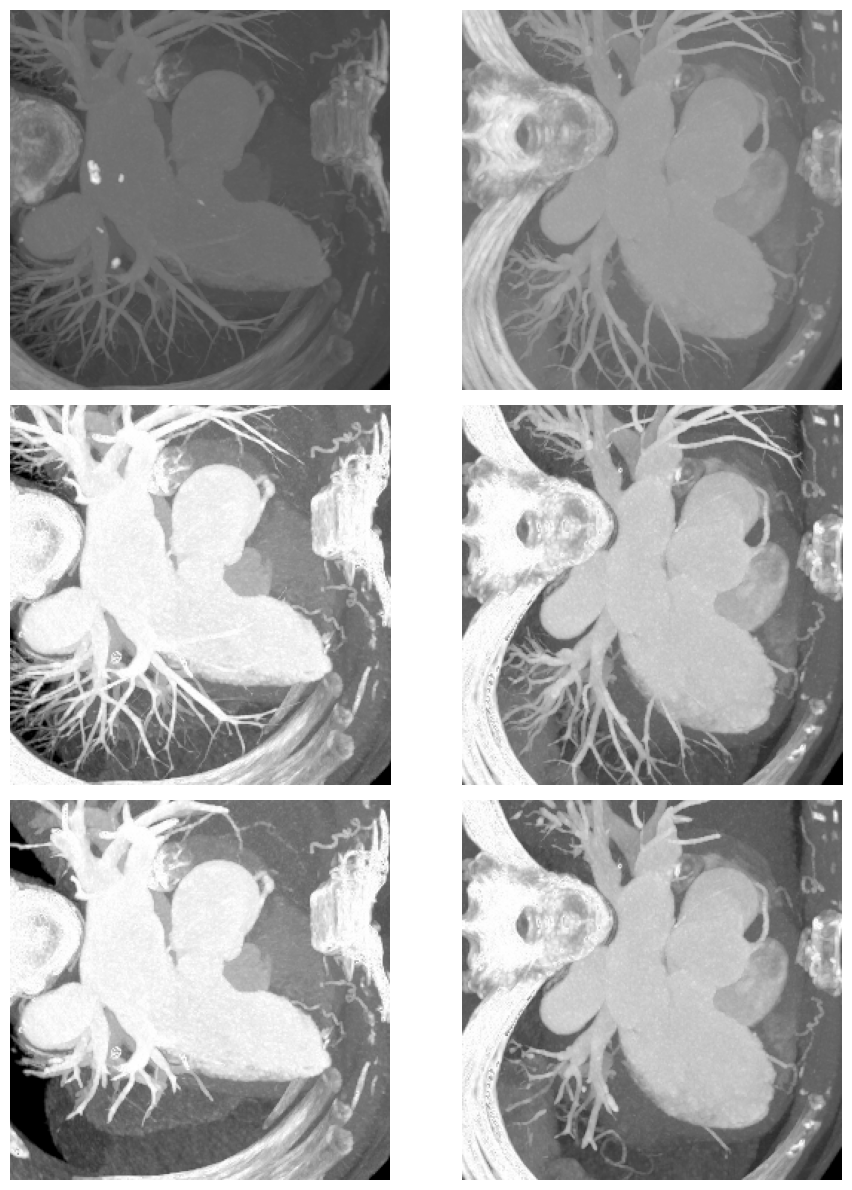

In [15]:
plot_preprocessing_grid(
    preprocessed,
    ids_to_plot=ids,
    mode="mip",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)


### Imagem reduzida - fatia central


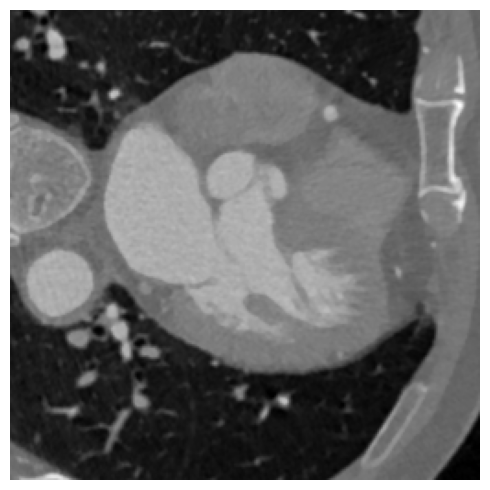

In [16]:
plot_stage(
    preprocessed,
    "down_image",
    "Imagem reduzida",
    img_id=90,
    mode="slice",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)


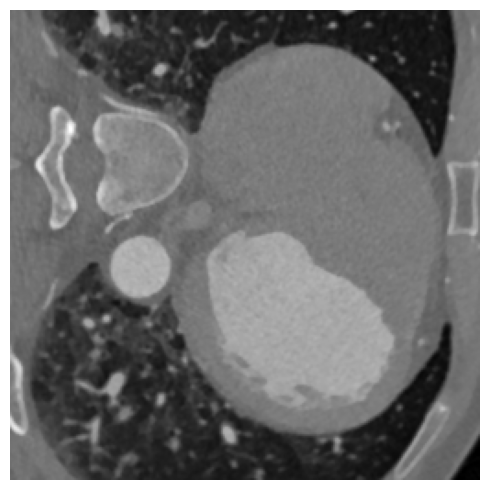

In [17]:
plot_stage(
    preprocessed,
    "down_image",
    "Imagem reduzida",
    img_id=774,
    mode="slice",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)


### Imagem reduzida - MIP axial


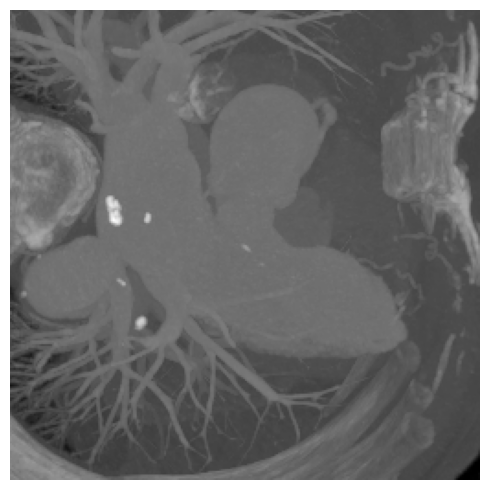

In [18]:
plot_stage(
    preprocessed,
    "down_image",
    "Imagem reduzida",
    img_id=90,
    mode="mip",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)


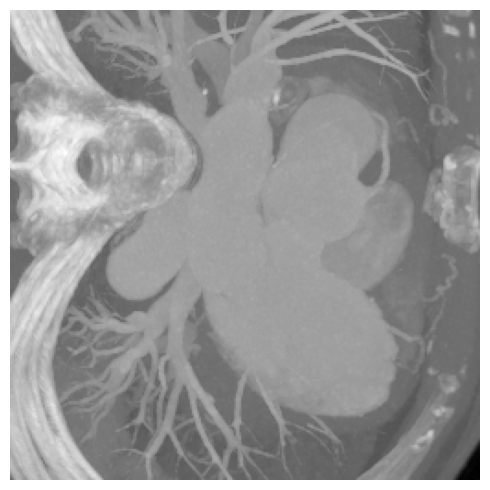

In [19]:
plot_stage(
    preprocessed,
    "down_image",
    "Imagem reduzida",
    img_id=774,
    mode="mip",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)


### Imagem limiarizada - fatia central


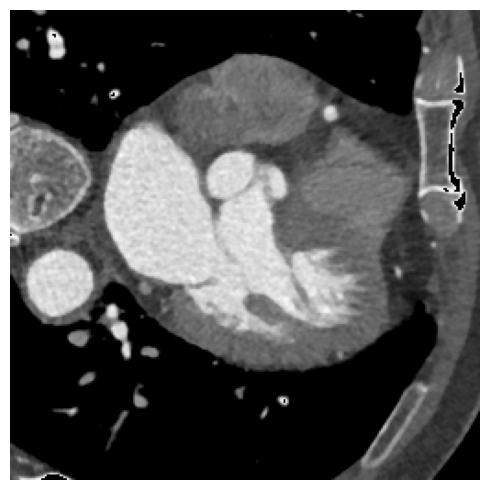

In [20]:
plot_stage(
    preprocessed,
    "thresh_image",
    "Imagem limiarizada",
    img_id=90,
    mode="slice",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)


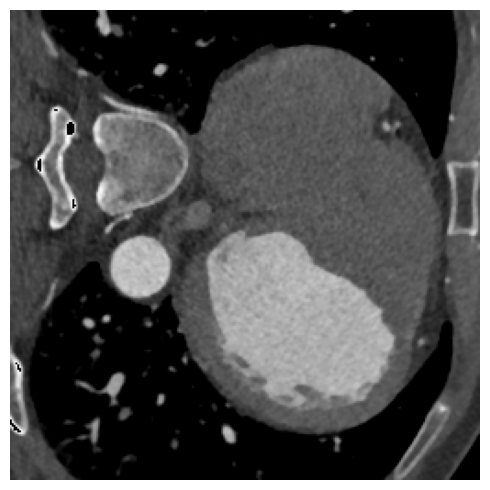

In [21]:
plot_stage(
    preprocessed,
    "thresh_image",
    "Imagem limiarizada",
    img_id=774,
    mode="slice",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)


### Imagem limiarizada - MIP axial


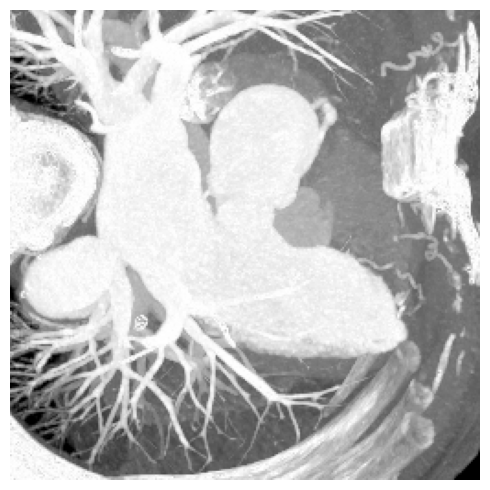

In [22]:
plot_stage(
    preprocessed,
    "thresh_image",
    "Imagem limiarizada",
    img_id=90,
    mode="mip",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)


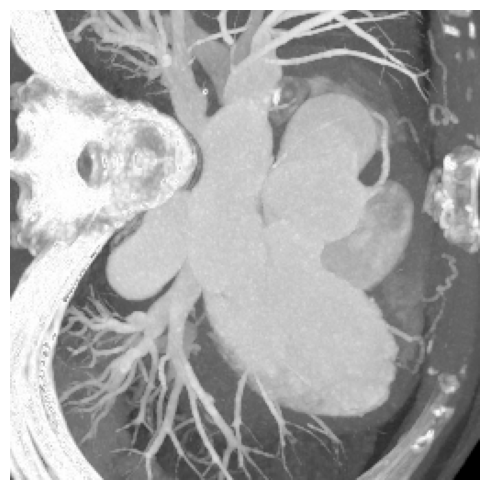

In [23]:
plot_stage(
    preprocessed,
    "thresh_image",
    "Imagem limiarizada",
    img_id=774,
    mode="mip",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)


### Imagem LCC - fatia central


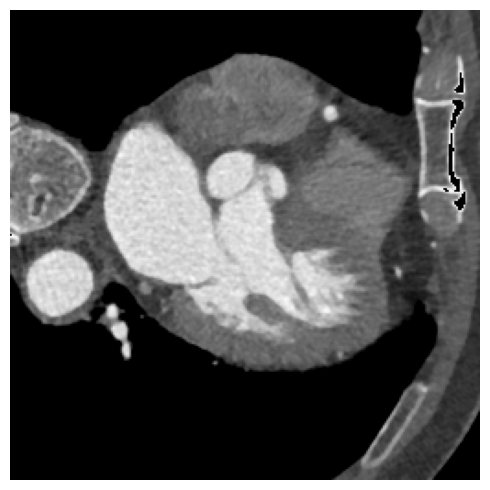

In [24]:
plot_stage(
    preprocessed,
    "lcc_image",
    "Imagem LCC",
    img_id=90,
    mode="slice",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)


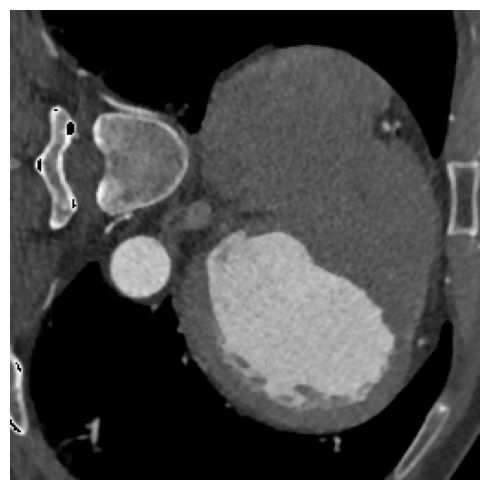

In [25]:
plot_stage(
    preprocessed,
    "lcc_image",
    "Imagem LCC",
    img_id=774,
    mode="slice",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)


### Imagem LCC - MIP axial


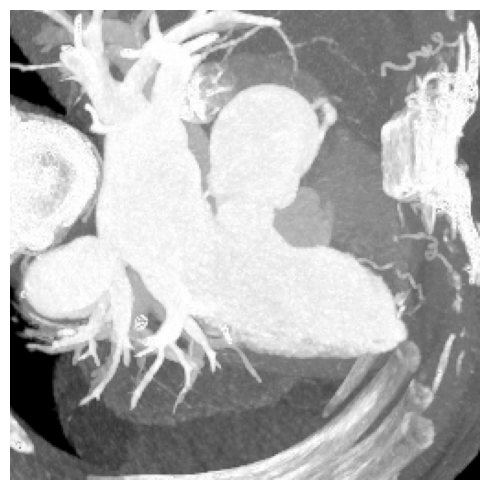

In [26]:
plot_stage(
    preprocessed,
    "lcc_image",
    "Imagem LCC",
    img_id=90,
    mode="mip",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)


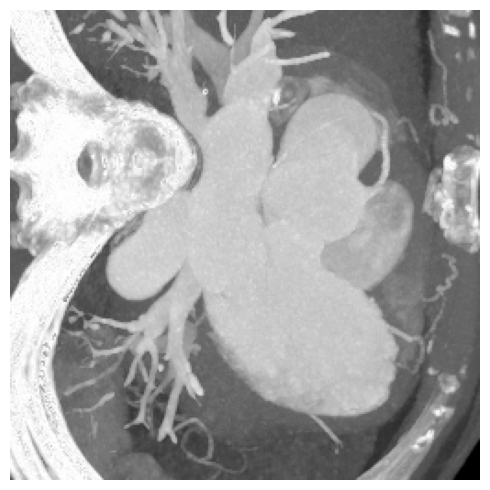

In [27]:
plot_stage(
    preprocessed,
    "lcc_image",
    "Imagem LCC",
    img_id=774,
    mode="mip",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
)


## Transformada de Hough

In [28]:

hough_diagnostics = {}
hough_detected_circles = {}

for img_id in ids:
    lcc_image = preprocessed[img_id]["lcc_image"]
    first_slice_idx = lcc_image.shape[2] - 1
    spacing = data[img_id]["spacing"]
    dx, dy, dz = (
        spacing[0] * CONFIG["DOWNSCALE_FACTORS"][0],
        spacing[1] * CONFIG["DOWNSCALE_FACTORS"][1],
        spacing[2] * CONFIG["DOWNSCALE_FACTORS"][2],
    )

    radii_start = CONFIG["CIRCLE_DETECTION"]["radii_start_px"]
    radii_end = CONFIG["CIRCLE_DETECTION"]["radii_end_px"]
    radius_step = CONFIG["CIRCLE_DETECTION"]["radius_step_px"]
    hough_radii = np.arange(radii_start, radii_end, radius_step)

    hough_diagnostics[img_id] = get_initial_circle_diagnostics(
        lcc_image[:, :, first_slice_idx],
        hough_radii,
        quadrant_offset=CONFIG["CIRCLE_DETECTION"]["quadrant_offset"],
        total_num_peaks_initial=CONFIG["CIRCLE_DETECTION"]["total_num_peaks_initial"],
        canny_sigma=CONFIG["CIRCLE_DETECTION"]["canny_sigma"],
        neighbor_distance_threshold=CONFIG["CIRCLE_DETECTION"]["neighbor_distance_threshold"],
    )

    hough_detected_circles[img_id] = get_or_detect_aorta_circles(
        img_id,
        lcc_image,
        CONFIG["DOWNSCALE_FACTORS"],
        (dx, dy, dz),
        CONFIG["CIRCLE_DETECTION"],
        base_save_path=None,
        load_cache=False,
        save_cache=False,
    )

Parada na fatia 135: Δr=4.00 ou dist=36.40
Parada na fatia 145: Δr=1.00 ou dist=42.19


### Círculo inicial - ID 90


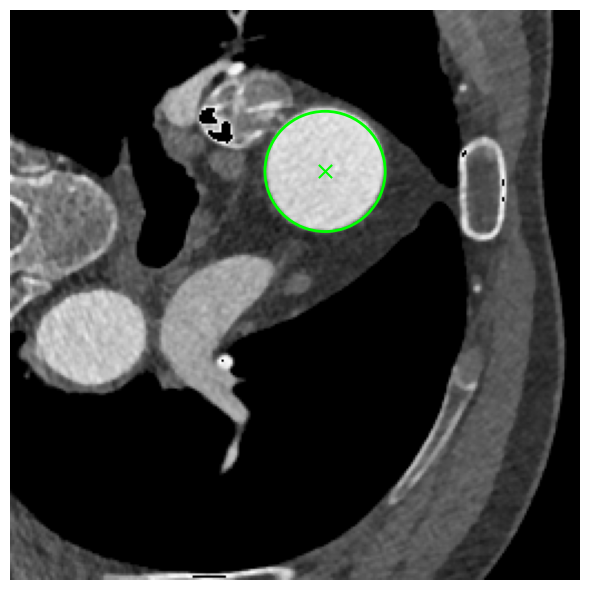

In [29]:
plot_hough_initial_circle(
    preprocessed[90]["lcc_image"][:, :, preprocessed[90]["lcc_image"].shape[2] - 1],
    hough_diagnostics[90],
    title="Transformada de Hough - ID 90 | círculo inicial",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
 )


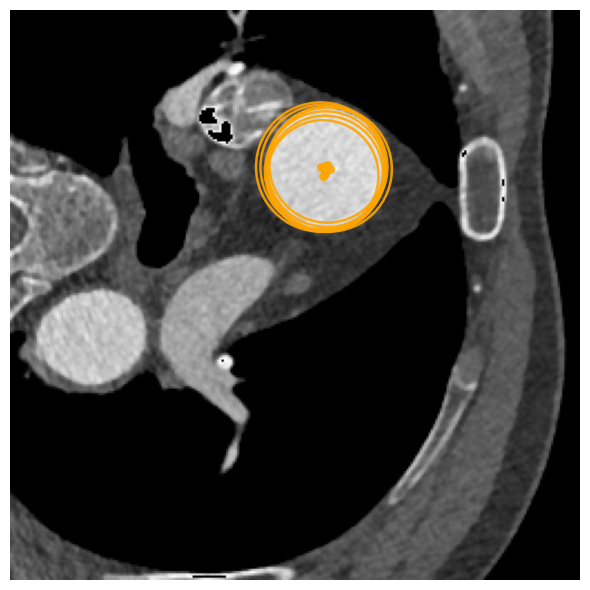

In [30]:
plot_hough_refinement_candidates(
    preprocessed[90]["lcc_image"][:, :, preprocessed[90]["lcc_image"].shape[2] - 1],
    hough_diagnostics[90],
    title="Transformada de Hough - ID 90 | círculos vizinhos para refinamento",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
 )


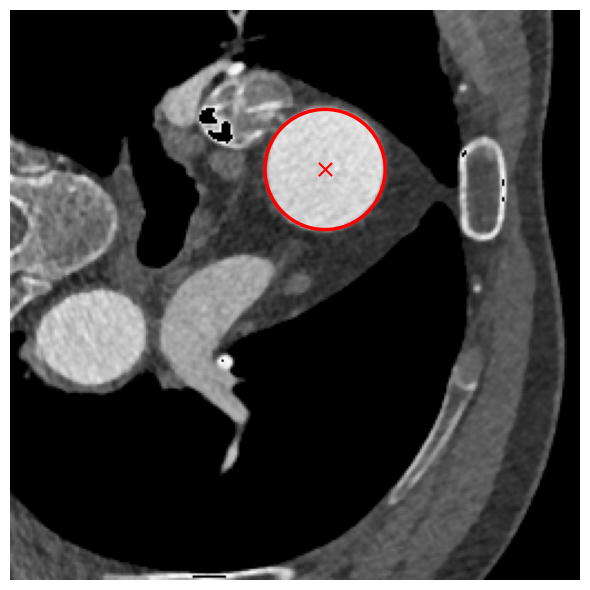

In [31]:
plot_hough_refined_circle(
    preprocessed[90]["lcc_image"][:, :, preprocessed[90]["lcc_image"].shape[2] - 1],
    hough_diagnostics[90],
    title="Transformada de Hough - ID 90 | círculo final refinado",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
 )


### Círculo inicial - ID 774


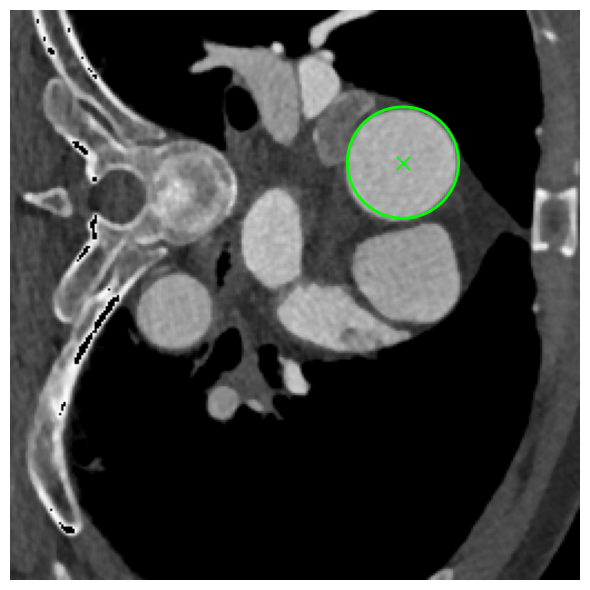

In [32]:
plot_hough_initial_circle(
    preprocessed[774]["lcc_image"][:, :, preprocessed[774]["lcc_image"].shape[2] - 1],
    hough_diagnostics[774],
    title="Transformada de Hough - ID 774 | círculo inicial",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
 )


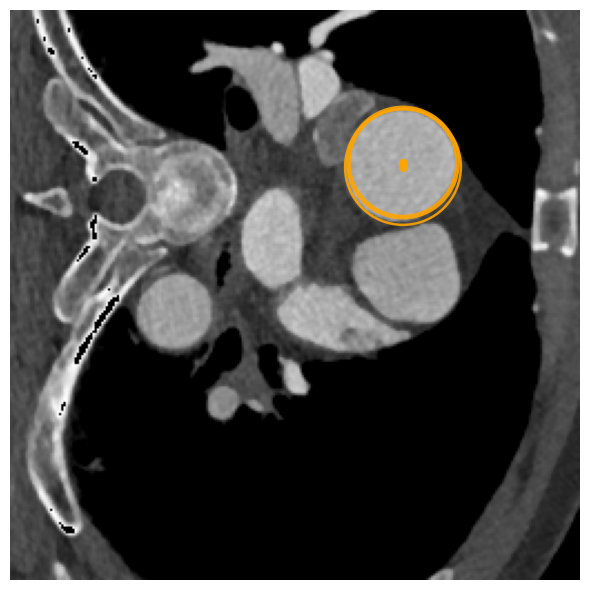

In [33]:
plot_hough_refinement_candidates(
    preprocessed[774]["lcc_image"][:, :, preprocessed[774]["lcc_image"].shape[2] - 1],
    hough_diagnostics[774],
    title="Transformada de Hough - ID 774 | círculos vizinhos para refinamento",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
 )


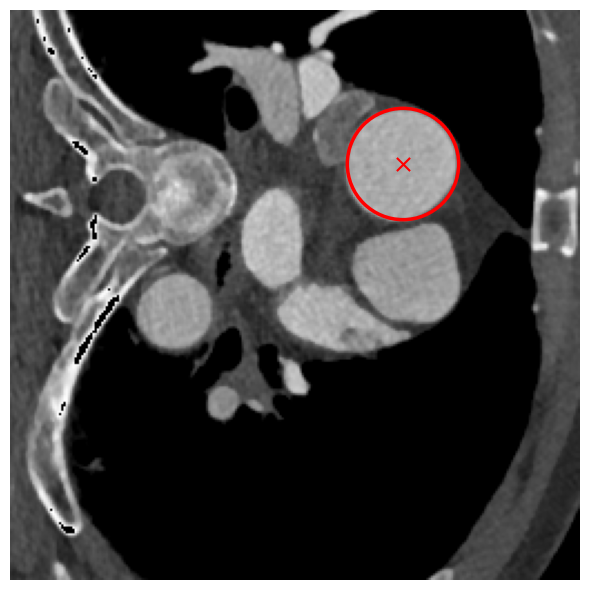

In [34]:
plot_hough_refined_circle(
    preprocessed[774]["lcc_image"][:, :, preprocessed[774]["lcc_image"].shape[2] - 1],
    hough_diagnostics[774],
    title="Transformada de Hough - ID 774 | círculo final refinado",
    show_title=PLOT_SHOW_TITLES,
    show_subtitle=PLOT_SHOW_SUBTITLES,
    dpi=PLOT_DPI,
 )


## Círculos refinados ao longo do volume


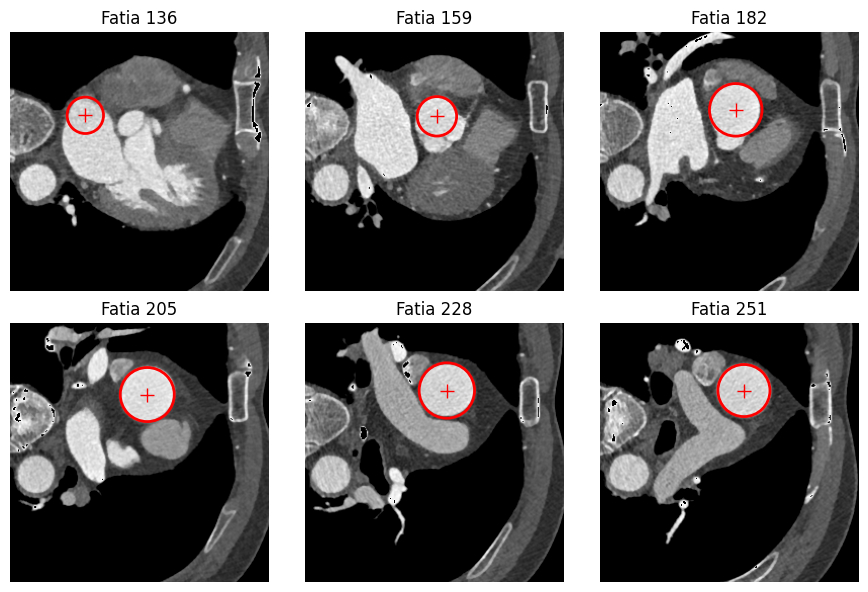

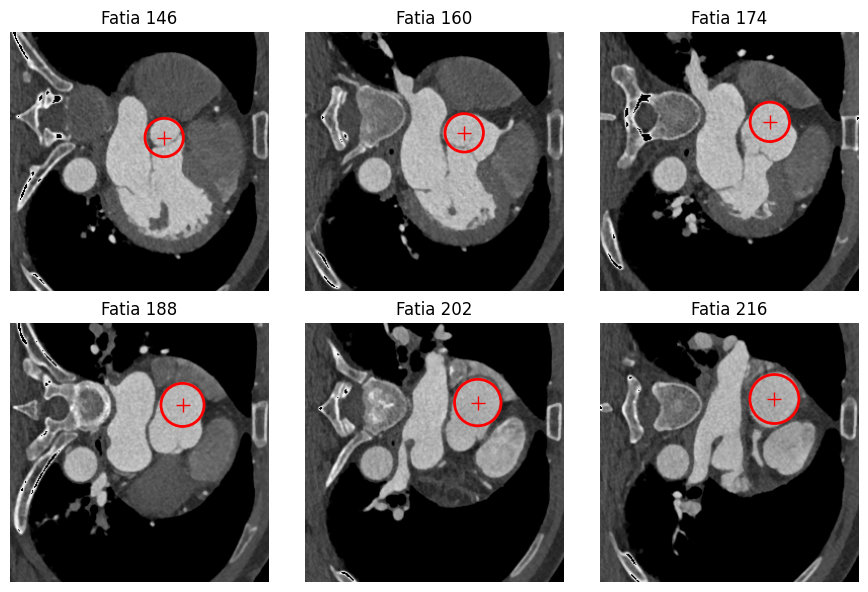

In [35]:
for img_id in ids:
    lcc_image = preprocessed[img_id]["lcc_image"]
    visualize_circles_on_slices(
        lcc_image,
        hough_detected_circles[img_id],
        num_samples=6,
        vmin=lcc_image.min(),
        vmax=lcc_image.max(),
        dpi=PLOT_DPI,
    )


### Círculos refinados espaçados - ID 90


### Círculos refinados espaçados - ID 774


## MIP dos mapas de vasos


In [36]:
if RUN_VESSELNESS:
    vessel_maps = compute_vesselness_maps(preprocessed, ids_to_plot=ids)
else:
    vessel_maps = {img_id: None for img_id in ids}


### Óstios

In [37]:
if RUN_VESSELNESS:
    plot_vesselness_mip(
        vessel_maps,
        img_id=90,
        map_key="vesselness_ostia",
        title="Mapa de vasos para ostios (MIP axial)",
        show_title=PLOT_SHOW_TITLES,
        show_subtitle=PLOT_SHOW_SUBTITLES,
        show_colorbar=PLOT_SHOW_COLORBAR,
        dpi=PLOT_DPI,
        cmap=PLOT_VESSELNESS_CMAP,
    )
else:
    print("Vesselness não executado: defina RUN_VESSELNESS = True.")

Vesselness não executado: defina RUN_VESSELNESS = True.


In [38]:
if RUN_VESSELNESS:
    plot_vesselness_mip(
        vessel_maps,
        img_id=774,
        map_key="vesselness_ostia",
        title="Mapa de vasos para ostios (MIP axial)",
        show_title=PLOT_SHOW_TITLES,
        show_subtitle=PLOT_SHOW_SUBTITLES,
        show_colorbar=PLOT_SHOW_COLORBAR,
        dpi=PLOT_DPI,
        cmap=PLOT_VESSELNESS_CMAP,
    )
else:
    print("Vesselness não executado: defina RUN_VESSELNESS = True.")

Vesselness não executado: defina RUN_VESSELNESS = True.


### Artérias

In [39]:
if RUN_VESSELNESS:
    plot_vesselness_mip(
        vessel_maps,
        img_id=90,
        map_key="vesselness_artery",
        title="Mapa de vasos para arterias (MIP axial)",
        show_title=PLOT_SHOW_TITLES,
        show_subtitle=PLOT_SHOW_SUBTITLES,
        show_colorbar=PLOT_SHOW_COLORBAR,
        dpi=PLOT_DPI,
        cmap=PLOT_VESSELNESS_CMAP,
    )
else:
    print("Vesselness não executado: defina RUN_VESSELNESS = True.")

Vesselness não executado: defina RUN_VESSELNESS = True.


In [40]:
if RUN_VESSELNESS:
    plot_vesselness_mip(
        vessel_maps,
        img_id=774,
        map_key="vesselness_artery",
        title="Mapa de vasos para arterias (MIP axial)",
        show_title=PLOT_SHOW_TITLES,
        show_subtitle=PLOT_SHOW_SUBTITLES,
        show_colorbar=PLOT_SHOW_COLORBAR,
        dpi=PLOT_DPI,
        cmap=PLOT_VESSELNESS_CMAP,
    )
else:
    print("Vesselness não executado: defina RUN_VESSELNESS = True.")

Vesselness não executado: defina RUN_VESSELNESS = True.


## Conclusão

A sequência de figuras permite inspecionar cada transformação antes da segmentação e localizar visualmente desvios no threshold, LCC, Hough ou vesselness.